In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from aeon.datasets import load_classification
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score

In [ ]:
# ============================================================
# 1) Config
# ============================================================
CONFIG = {
    "seed": 42,
    "batch_size": 16,
    "hidden_dim": 64,
    "lr": 1e-3,
    "epochs_task1": 30,
    "epochs_task2": 30,
    "ewc_lambda": 200.0,
    "lwf_alpha": 1.0,
    "lwf_temperature": 2.0,
    "replay_per_class": 100,
    "target_length": 150,
    "task1_name": "GunPoint",
    "task2_name": "SonyAIBORobotSurface1",
}

In [ ]:
# ============================================================
# 2) Reproducibility
# ============================================================
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


In [ ]:
# ============================================================
# 3) Time-series preprocessing
# ============================================================
def resize_1d_series(x, target_length):
    """
    Resize 1D time series using linear interpolation.
    x shape: (length,)
    returns shape: (target_length,)
    """
    old_idx = np.linspace(0, 1, len(x))
    new_idx = np.linspace(0, 1, target_length)
    return np.interp(new_idx, old_idx, x).astype(np.float32)

def preprocess_aeon_dataset(dataset_name, target_length=150):
    X_train, y_train = load_classification(dataset_name, split="train")
    X_test, y_test = load_classification(dataset_name, split="test")

    if X_train.ndim == 3:
        X_train = X_train[:, 0, :]
        X_test = X_test[:, 0, :]
    elif X_train.ndim == 2:
        pass
    else:
        raise ValueError(f"Unexpected shape for {dataset_name}: {X_train.shape}")

    # Resize all series to same length
    X_train_resized = np.array([resize_1d_series(x, target_length) for x in X_train], dtype=np.float32)
    X_test_resized = np.array([resize_1d_series(x, target_length) for x in X_test], dtype=np.float32)

    # Encode labels
    le = LabelEncoder()
    y_train = le.fit_transform(y_train)
    y_test = le.transform(y_test)

    num_classes = len(np.unique(y_train))
    if num_classes != 2:
        raise ValueError(f"{dataset_name} is not binary. Found {num_classes} classes.")

    # Standardize per dataset
    scaler = StandardScaler()
    X_train_resized = scaler.fit_transform(X_train_resized).astype(np.float32)
    X_test_resized = scaler.transform(X_test_resized).astype(np.float32)

    return X_train_resized, y_train, X_test_resized, y_test

def make_loader(X, y, batch_size=16, shuffle=True):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


In [ ]:
# ============================================================
# 4) Model
# ============================================================
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.net(x)


In [ ]:
# ============================================================
# 5) Train
# ============================================================
def evaluate_model(model, loader, device):
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1)
            preds.extend(pred.cpu().numpy())
            targets.extend(yb.cpu().numpy())

    return accuracy_score(targets, preds)

def train_model(model, loader, optimizer, device, epochs=20, extra_loss_fn=None):
    ce_loss = nn.CrossEntropyLoss()
    model.train()

    for epoch in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = ce_loss(logits, yb)

            if extra_loss_fn is not None:
                loss = loss + extra_loss_fn(model, xb, yb, logits)

            loss.backward()
            optimizer.step()

    return model


In [ ]:
# ============================================================
# 6) Metrics
# ============================================================
def forgetting_score(task1_before, task1_after):
    return task1_before - task1_after

def average_accuracy(task1_after, task2_after):
    return 0.5 * (task1_after + task2_after)


In [ ]:
# ============================================================
# 7) EWC
# ============================================================
def compute_fisher(model, loader, device):
    model.eval()
    fisher = {n: torch.zeros_like(p) for n, p in model.named_parameters()}
    ce_loss = nn.CrossEntropyLoss()

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        model.zero_grad()
        logits = model(xb)
        loss = ce_loss(logits, yb)
        loss.backward()

        for n, p in model.named_parameters():
            if p.grad is not None:
                fisher[n] += p.grad.detach() ** 2

    for n in fisher:
        fisher[n] /= len(loader)

    return fisher

def clone_params(model):
    return {n: p.detach().clone() for n, p in model.named_parameters()}

def make_ewc_loss(fisher, old_params, ewc_lambda):
    def ewc_loss(model, xb, yb, logits):
        loss_val = 0.0
        for n, p in model.named_parameters():
            loss_val += (fisher[n] * (p - old_params[n]) ** 2).sum()
        return 0.5 * ewc_lambda * loss_val
    return ewc_loss


In [ ]:
# ============================================================
# 8) LwF
# ============================================================
def make_lwf_loss(teacher_model, alpha=1.0, temperature=2.0):
    kl = nn.KLDivLoss(reduction="batchmean")

    def lwf_loss(model, xb, yb, logits):
        with torch.no_grad():
            teacher_logits = teacher_model(xb)

        student_log_probs = torch.log_softmax(logits / temperature, dim=1)
        teacher_probs = torch.softmax(teacher_logits / temperature, dim=1)
        distill_loss = kl(student_log_probs, teacher_probs) * (temperature ** 2)

        return alpha * distill_loss

    return lwf_loss

In [ ]:
# ============================================================
# 9) Replay
# ============================================================
def fit_class_gaussians(X, y):
    stats = {}
    for c in np.unique(y):
        Xc = X[y == c]
        mean = Xc.mean(axis=0)
        var = Xc.var(axis=0) + 1e-4
        stats[c] = (mean, var)
    return stats

def sample_gaussian_replay(stats, n_per_class=100):
    Xs, ys = [], []
    for c, (mean, var) in stats.items():
        samples = np.random.randn(n_per_class, len(mean)) * np.sqrt(var) + mean
        Xs.append(samples.astype(np.float32))
        ys.append(np.full(n_per_class, c))
    return np.vstack(Xs), np.concatenate(ys)


In [ ]:
# ============================================================
# 10) Experiment runners
# ============================================================
def run_baseline(loaders, input_dim, num_classes, config, device):
    model = MLP(input_dim, config["hidden_dim"], num_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])

    train_model(model, loaders["train_t1"], optimizer, device, epochs=config["epochs_task1"])
    task1_before = evaluate_model(model, loaders["test_t1"], device)

    train_model(model, loaders["train_t2"], optimizer, device, epochs=config["epochs_task2"])
    task1_after = evaluate_model(model, loaders["test_t1"], device)
    task2_after = evaluate_model(model, loaders["test_t2"], device)

    return {
        "method": "Baseline",
        "task1_before": task1_before,
        "task1_after": task1_after,
        "task2_after": task2_after,
        "forgetting": forgetting_score(task1_before, task1_after),
        "avg_acc": average_accuracy(task1_after, task2_after),
    }

def run_ewc(loaders, input_dim, num_classes, config, device):
    model = MLP(input_dim, config["hidden_dim"], num_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])

    train_model(model, loaders["train_t1"], optimizer, device, epochs=config["epochs_task1"])
    task1_before = evaluate_model(model, loaders["test_t1"], device)

    fisher = compute_fisher(model, loaders["train_t1"], device)
    old_params = clone_params(model)
    ewc_loss = make_ewc_loss(fisher, old_params, config["ewc_lambda"])

    train_model(model, loaders["train_t2"], optimizer, device, epochs=config["epochs_task2"], extra_loss_fn=ewc_loss)
    task1_after = evaluate_model(model, loaders["test_t1"], device)
    task2_after = evaluate_model(model, loaders["test_t2"], device)

    return {
        "method": "EWC",
        "task1_before": task1_before,
        "task1_after": task1_after,
        "task2_after": task2_after,
        "forgetting": forgetting_score(task1_before, task1_after),
        "avg_acc": average_accuracy(task1_after, task2_after),
    }

def run_lwf(loaders, input_dim, num_classes, config, device):
    model = MLP(input_dim, config["hidden_dim"], num_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])

    train_model(model, loaders["train_t1"], optimizer, device, epochs=config["epochs_task1"])
    task1_before = evaluate_model(model, loaders["test_t1"], device)

    teacher = deepcopy(model).to(device)
    teacher.eval()

    lwf_loss = make_lwf_loss(
        teacher_model=teacher,
        alpha=config["lwf_alpha"],
        temperature=config["lwf_temperature"]
    )

    train_model(model, loaders["train_t2"], optimizer, device, epochs=config["epochs_task2"], extra_loss_fn=lwf_loss)
    task1_after = evaluate_model(model, loaders["test_t1"], device)
    task2_after = evaluate_model(model, loaders["test_t2"], device)

    return {
        "method": "LwF",
        "task1_before": task1_before,
        "task1_after": task1_after,
        "task2_after": task2_after,
        "forgetting": forgetting_score(task1_before, task1_after),
        "avg_acc": average_accuracy(task1_after, task2_after),
    }

def run_dgr_like(loaders, task1_data, task2_data, input_dim, num_classes, config, device):
    model = MLP(input_dim, config["hidden_dim"], num_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])

    train_model(model, loaders["train_t1"], optimizer, device, epochs=config["epochs_task1"])
    task1_before = evaluate_model(model, loaders["test_t1"], device)

    X1_train, y1_train = task1_data
    X2_train, y2_train = task2_data

    stats = fit_class_gaussians(X1_train, y1_train)
    X_replay, y_replay = sample_gaussian_replay(stats, n_per_class=config["replay_per_class"])

    X_mix = np.vstack([X2_train, X_replay]).astype(np.float32)
    y_mix = np.concatenate([y2_train, y_replay])

    replay_loader = make_loader(X_mix, y_mix, batch_size=config["batch_size"], shuffle=True)

    train_model(model, replay_loader, optimizer, device, epochs=config["epochs_task2"])
    task1_after = evaluate_model(model, loaders["test_t1"], device)
    task2_after = evaluate_model(model, loaders["test_t2"], device)

    return {
        "method": "DGR-like",
        "task1_before": task1_before,
        "task1_after": task1_after,
        "task2_after": task2_after,
        "forgetting": forgetting_score(task1_before, task1_after),
        "avg_acc": average_accuracy(task1_after, task2_after),
    }

In [ ]:
# ============================================================
# 11) Prepare experiment
# ============================================================
def prepare_experiment(config):
    X1_train, y1_train, X1_test, y1_test = preprocess_aeon_dataset(
        config["task1_name"], target_length=config["target_length"]
    )
    X2_train, y2_train, X2_test, y2_test = preprocess_aeon_dataset(
        config["task2_name"], target_length=config["target_length"]
    )

    loaders = {
        "train_t1": make_loader(X1_train, y1_train, batch_size=config["batch_size"], shuffle=True),
        "test_t1": make_loader(X1_test, y1_test, batch_size=config["batch_size"], shuffle=False),
        "train_t2": make_loader(X2_train, y2_train, batch_size=config["batch_size"], shuffle=True),
        "test_t2": make_loader(X2_test, y2_test, batch_size=config["batch_size"], shuffle=False),
    }

    input_dim = X1_train.shape[1]
    num_classes = 2

    return loaders, (X1_train, y1_train), (X2_train, y2_train), input_dim, num_classes


In [ ]:
# ============================================================
# 12) Run all methods
# ============================================================
def run_all_methods(config, device):
    loaders, task1_data, task2_data, input_dim, num_classes = prepare_experiment(config)

    results = []
    results.append(run_baseline(loaders, input_dim, num_classes, config, device))
    results.append(run_ewc(loaders, input_dim, num_classes, config, device))
    results.append(run_lwf(loaders, input_dim, num_classes, config, device))
    results.append(run_dgr_like(loaders, task1_data, task2_data, input_dim, num_classes, config, device))

    return pd.DataFrame(results)


Using device: cpu


/tmp/ipykernel_8186/1057826.py:61: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp/ipykernel_8186/1057826.py:62: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test, y_test = load_classification(dataset_name, split="test")
/tmp/ipykernel_8186/1057826.py:61: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp/ip


=== Continual Learning Results: GunPoint -> SonyAIBORobotSurface1 ===


,method,task1_before,task1_after,task2_after,forgetting,avg_acc
0,Baseline,0.866667,0.686667,0.733777,0.18,0.710222
1,EWC,0.906667,0.886667,0.730449,0.02,0.808558
2,LwF,0.880000,0.840000,0.622296,0.04,0.731148
3,DGR-like,0.853333,0.813333,0.692180,0.04,0.752757


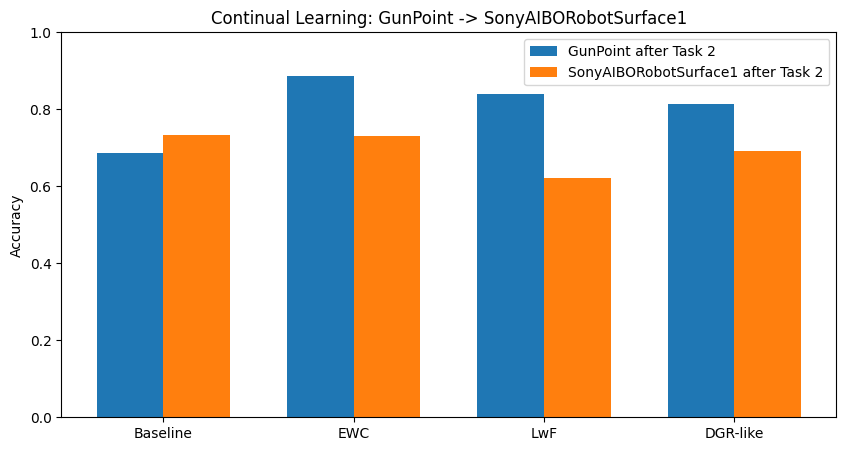

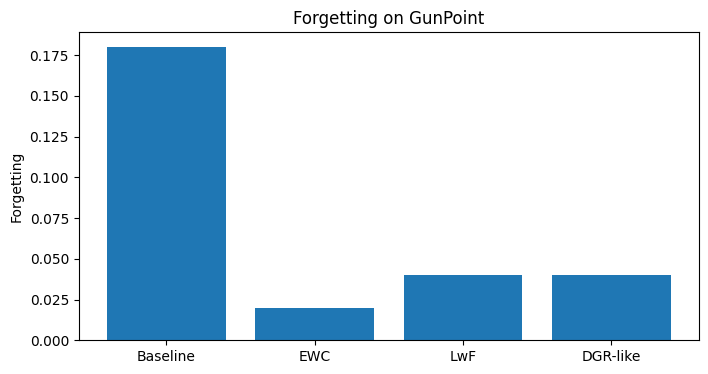

In [ ]:
# ============================================================
# 13) Plotting
# ============================================================
def plot_results(df, task1_name, task2_name):
    methods = df["method"].values
    task1_after = df["task1_after"].values
    task2_after = df["task2_after"].values
    forgetting = df["forgetting"].values

    x = np.arange(len(methods))
    width = 0.35

    plt.figure(figsize=(10, 5))
    plt.bar(x - width/2, task1_after, width, label=f"{task1_name} after Task 2")
    plt.bar(x + width/2, task2_after, width, label=f"{task2_name} after Task 2")
    plt.xticks(x, methods)
    plt.ylim(0, 1.0)
    plt.ylabel("Accuracy")
    plt.title(f"Continual Learning: {task1_name} -> {task2_name}")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.bar(methods, forgetting)
    plt.ylabel("Forgetting")
    plt.title(f"Forgetting on {task1_name}")
    plt.show()

# ============================================================
# 14) Run
# ============================================================
results_df = run_all_methods(CONFIG, device)

print(f"\n=== Continual Learning Results: {CONFIG['task1_name']} -> {CONFIG['task2_name']} ===")
display(results_df)

plot_results(results_df, CONFIG["task1_name"], CONFIG["task2_name"])